<a href="https://www.kaggle.com/code/sofiatanganho/2-0-modela-o-treino?scriptVersionId=320295155" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Análise Preditiva do Mercado Imobiliário de Boston
#### Grupo 10: Diana Figueiredo, Natacha Zhang, Sofia Tanganho
#### Docente: Dora Melo 

## Importação de Bibliotecas
(Diana Figueiredo)

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from scipy.stats import kstest, norm

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import (
    train_test_split,
    KFold,
    ParameterGrid,
    GridSearchCV,           
    RandomizedSearchCV,    
    cross_validate,        
    learning_curve          
)
from sklearn.pipeline import Pipeline                  
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    silhouette_score,
    silhouette_samples,
    calinski_harabasz_score,    
    davies_bouldin_score        
)

from xgboost import XGBRegressor
from sklearn.utils import resample

In [72]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/natachazhang/dados-processados/boston_processed.csv


In [73]:
warnings.filterwarnings("ignore")

In [74]:
df = pd.read_csv("/kaggle/input/datasets/natachazhang/dados-processados/boston_processed.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ZN          506 non-null    float64
 1   INDUS       506 non-null    float64
 2   CHAS        506 non-null    int64  
 3   AGE         506 non-null    float64
 4   TAX         506 non-null    float64
 5   B           506 non-null    float64
 6   MEDV        506 non-null    float64
 7   B_stand     506 non-null    float64
 8   ZN_stand    506 non-null    float64
 9   INDUS_norm  506 non-null    float64
 10  AGE_norm    506 non-null    float64
 11  TAX_norm    506 non-null    float64
 12  IQV         506 non-null    float64
 13  IAH         506 non-null    float64
 14  IQV_stand   506 non-null    float64
 15  IAH_stand   506 non-null    float64
dtypes: float64(15), int64(1)
memory usage: 63.4 KB


In [75]:
df.describe()

,ZN,INDUS,CHAS,AGE,TAX,B,MEDV,B_stand,ZN_stand,INDUS_norm,AGE_norm,TAX_norm,IQV,IAH,IQV_stand,IAH_stand
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,5.060000e+02,5.060000e+02,506.000000,506.000000,506.000000,506.000000,506.000000,5.060000e+02,5.060000e+02
mean,11.363636,11.136779,0.069170,68.574901,408.237154,356.674032,22.532806,-7.582867e-16,1.140941e-16,0.391378,0.676364,0.422208,11.679929,0.222874,1.263811e-16,-1.053176e-16
std,23.322453,6.860353,0.253994,28.148861,168.537116,91.294864,9.197104,1.000990e+00,1.000990e+00,0.251479,0.289896,0.321636,16.242551,0.214639,1.000990e+00,1.000990e+00
min,0.000000,0.460000,0.000000,2.900000,187.000000,0.320000,5.000000,-3.907193e+00,-4.877224e-01,0.000000,0.000000,0.000000,1.446206,0.029853,-6.306800e-01,-9.001729e-01
25%,0.000000,5.190000,0.000000,45.025000,279.000000,375.377500,17.025000,2.050715e-01,-4.877224e-01,0.173387,0.433831,0.175573,1.883696,0.123168,-6.037184e-01,-4.649868e-01
50%,0.000000,9.690000,0.000000,77.500000,330.000000,391.440000,21.200000,3.811865e-01,-4.877224e-01,0.338343,0.768280,0.272901,5.739009,0.166978,-3.661247e-01,-2.606775e-01
75%,12.500000,18.100000,0.000000,94.075000,666.000000,396.225000,25.000000,4.336510e-01,4.877224e-02,0.646628,0.938980,0.914122,14.532372,0.235522,1.757892e-01,5.898866e-02
max,100.000000,27.740000,1.000000,100.000000,711.000000,396.900000,50.000000,4.410519e-01,3.804234e+00,1.000000,1.000000,1.000000,160.151944,2.196409,9.149976e+00,9.203776e+00


## Objetivo 1: Construir um modelo de previsão supervisionada do preço médio das habitações (MEDV), alcançando um R² superior a 0.80 e um RMSE inferior a 3.500 dólares, até ao Milestone 3.
### Baseline: 
- Regressão Linear 
### Algoritmos candidatos:
- Random Forest
- XGBoost
- SVR




### Experimentação de valores para treino de 80% e teste de 20%
(Sofia Tanganho)

In [76]:
# Divisão 80% treino / 20% teste
X = df[[
    'ZN_stand',      
    'INDUS_norm',   
    'CHAS',          
    'AGE_norm',      
    'TAX_norm',     
    'B_stand',       
    'IQV_stand',    
    'IAH_stand'     
]]

y = df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Treino: {X_train.shape}")
print(f"Teste: {X_test.shape}")

Treino: (404, 8)
Teste: (102, 8)


In [77]:
baseline = LinearRegression()
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

rmse_bl = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
mae_bl = mean_absolute_error(y_test, y_pred_baseline)
r2_bl = r2_score(y_test, y_pred_baseline)

print('Regressão Linear')
print(f"RMSE: {rmse_bl:.4f}")
print(f"MAE:  {mae_bl:.4f}")
print(f"R²:   {r2_bl:.4f}")

Regressão Linear
RMSE: 4.7511
MAE:  3.3544
R²:   0.6922


## Modelos candidatos 

(Natacha Zhang) 

Testaram-se três algoritmos:

* **Random Forest** – Algoritmo de ensemble que utiliza várias árvores de decisão para melhorar a performance, destacando-se pela sua robustez a outliers e capacidade de lidar com variáveis heterogéneas.
  
* **XGBoost** – Algoritmo de boosting avançado que constrói modelos de forma sequencial, corrigindo os erros das iterações anteriores e incorporando regularização para reduzir o overfitting.

* **SVR** – Modelo de regressão baseado em vetores de suporte que procura encontrar a função que melhor se ajusta aos dados dentro de uma margem de tolerância definida.

In [78]:
# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf_train = rf.predict(X_train)
y_pred_rf_test = rf.predict(X_test)

rmse_rf_train = np.sqrt(mean_squared_error(y_train, y_pred_rf_train))
rmse_rf_test = np.sqrt(mean_squared_error(y_test, y_pred_rf_test))
mae_rf_train = mean_absolute_error(y_train, y_pred_rf_train)
mae_rf_test = mean_absolute_error(y_test, y_pred_rf_test)
r2_rf_train = r2_score(y_train, y_pred_rf_train)
r2_rf_test = r2_score(y_test, y_pred_rf_test)

print("Random Forest")
print(f"RMSE Treino: {rmse_rf_train:.4f} | RMSE Teste: {rmse_rf_test:.4f}")
print(f"MAE  Treino: {mae_rf_train:.4f} | MAE  Teste: {mae_rf_test:.4f}")
print(f"R²   Treino: {r2_rf_train:.4f} | R²   Teste: {r2_rf_test:.4f}")

Random Forest
RMSE Treino: 1.5205 | RMSE Teste: 3.8309
MAE  Treino: 1.0570 | MAE  Teste: 2.6729
R²   Treino: 0.9734 | R²   Teste: 0.7999


In [79]:
# XGBoost
xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb_train = xgb.predict(X_train)
y_pred_xgb_test = xgb.predict(X_test)

rmse_xgb_train = np.sqrt(mean_squared_error(y_train, y_pred_xgb_train))
rmse_xgb_test = np.sqrt(mean_squared_error(y_test, y_pred_xgb_test))
mae_xgb_train = mean_absolute_error(y_train, y_pred_xgb_train)
mae_xgb_test = mean_absolute_error(y_test, y_pred_xgb_test)
r2_xgb_train = r2_score(y_train, y_pred_xgb_train)
r2_xgb_test = r2_score(y_test, y_pred_xgb_test)

print("XGBOOST")
print(f"RMSE Treino: {rmse_xgb_train:.4f} | RMSE Teste: {rmse_xgb_test:.4f}")
print(f"MAE  Treino: {mae_xgb_train:.4f} | MAE  Teste: {mae_xgb_test:.4f}")
print(f"R²   Treino: {r2_xgb_train:.4f} | R²   Teste: {r2_xgb_test:.4f}")

XGBOOST
RMSE Treino: 0.0509 | RMSE Teste: 3.6863
MAE  Treino: 0.0356 | MAE  Teste: 2.7311
R²   Treino: 1.0000 | R²   Teste: 0.8147


In [80]:
# SVR
svr = SVR(kernel='rbf')
svr.fit(X_train, y_train)

y_pred_svr_train = svr.predict(X_train)
rmse_svr_train = np.sqrt(mean_squared_error(y_train, y_pred_svr_train))
mae_svr_train = mean_absolute_error(y_train, y_pred_svr_train)
r2_svr_train = r2_score(y_train, y_pred_svr_train)

y_pred_svr_test = svr.predict(X_test)
rmse_svr_test = np.sqrt(mean_squared_error(y_test, y_pred_svr_test))
mae_svr_test = mean_absolute_error(y_test, y_pred_svr_test)
r2_svr_test = r2_score(y_test, y_pred_svr_test)

print("SVR")
print(f"RMSE Treino: {rmse_svr_train:.4f} | RMSE Teste: {rmse_svr_test:.4f}")
print(f"MAE  Treino: {mae_svr_train:.4f} | MAE  Teste: {mae_svr_test:.4f}")
print(f"R²   Treino: {r2_svr_train:.4f} | R²   Teste: {r2_svr_test:.4f}")


SVR
RMSE Treino: 5.3752 | RMSE Teste: 5.2674
MAE  Treino: 3.6694 | MAE  Teste: 3.3116
R²   Treino: 0.6674 | R²   Teste: 0.6217


In [81]:
resultados = pd.DataFrame({
    'Modelo': ['Random Forest', 'XGBoost', 'SVR'],
    'RMSE Treino': [ rmse_rf_train, rmse_xgb_train, rmse_svr_train],
    'RMSE Teste':  [ rmse_rf_test, rmse_xgb_test, rmse_svr_test],
    'MAE Treino':  [ mae_rf_train, mae_xgb_train, mae_svr_train],
    'MAE Teste':   [ mae_rf_test, mae_xgb_test, mae_svr_test],
    'R² Treino':   [ r2_rf_train, r2_xgb_train, r2_svr_train],
    'R² Teste':    [ r2_rf_test, r2_xgb_test, r2_svr_test]
})

print("Resultados dos modelos usando divisão treino/teste (80%/20%)")
print(resultados.to_string(index=False))

Resultados dos modelos usando divisão treino/teste (80%/20%)
       Modelo  RMSE Treino  RMSE Teste  MAE Treino  MAE Teste  R² Treino  R² Teste
Random Forest     1.520516    3.830944    1.056970   2.672922   0.973387  0.799872
      XGBoost     0.050864    3.686294    0.035627   2.731074   0.999970  0.814700
          SVR     5.375232    5.267405    3.669391   3.311626   0.667411  0.621654


#### Observações:

O **XGBoost** destaca-se como o modelo com melhor desempenho, apresentando o RMSE de teste mais baixo (3.686) e um R² de teste de 0.81, acima do objetivo SMART definido (R² > 0.80). O **Random Forest** apresenta resultados igualmente satisfatórios (R² teste = 0.80), no entanto ambos revelam sinais de overfitting, com valores de R² de treino muito superiores aos de teste.
O **SVR** apresenta o desempenho mais fraco, não atingindo o objetivo definido (R² teste = 0.62).

### Experimentação de valores para treino de 70% e teste de 30%
(Sofia Tanganho)

In [82]:
X = df[[
    'ZN_stand',      
    'INDUS_norm',    
    'CHAS',          
    'AGE_norm',      
    'TAX_norm',      
    'B_stand',       
    'IQV_stand',   
    'IAH_stand'      
]]

y = df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Treino: {X_train.shape}")
print(f"Teste: {X_test.shape}")

Treino: (354, 8)
Teste: (152, 8)


In [83]:
# Treinar Baseline
baseline = LinearRegression()
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)


rmse_bl = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
mae_bl = mean_absolute_error(y_test, y_pred_baseline)
r2_bl = r2_score(y_test, y_pred_baseline)

print("Regressão Linear")
print(f"RMSE: {rmse_bl:.4f}")
print(f"MAE:  {mae_bl:.4f}")
print(f"R²:   {r2_bl:.4f}")

Regressão Linear
RMSE: 4.8757
MAE:  3.5549
R²:   0.6810


In [84]:
# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf_train = rf.predict(X_train)
y_pred_rf_test = rf.predict(X_test)

rmse_rf_train = np.sqrt(mean_squared_error(y_train, y_pred_rf_train))
rmse_rf_test = np.sqrt(mean_squared_error(y_test, y_pred_rf_test))
mae_rf_train = mean_absolute_error(y_train, y_pred_rf_train)
mae_rf_test = mean_absolute_error(y_test, y_pred_rf_test)
r2_rf_train = r2_score(y_train, y_pred_rf_train)
r2_rf_test = r2_score(y_test, y_pred_rf_test)

print("RANDOM FOREST")
print(f"RMSE Treino: {rmse_rf_train:.4f} | RMSE Teste: {rmse_rf_test:.4f}")
print(f"MAE  Treino: {mae_rf_train:.4f} | MAE  Teste: {mae_rf_test:.4f}")
print(f"R²   Treino: {r2_rf_train:.4f} | R²   Teste: {r2_rf_test:.4f}")

RANDOM FOREST
RMSE Treino: 1.6594 | RMSE Teste: 3.5936
MAE  Treino: 1.1323 | MAE  Teste: 2.5627
R²   Treino: 0.9687 | R²   Teste: 0.8267


In [85]:
# XGBoost
xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb_train = xgb.predict(X_train)
y_pred_xgb_test = xgb.predict(X_test)

rmse_xgb_train = np.sqrt(mean_squared_error(y_train, y_pred_xgb_train))
rmse_xgb_test = np.sqrt(mean_squared_error(y_test, y_pred_xgb_test))
mae_xgb_train = mean_absolute_error(y_train, y_pred_xgb_train)
mae_xgb_test = mean_absolute_error(y_test, y_pred_xgb_test)
r2_xgb_train = r2_score(y_train, y_pred_xgb_train)
r2_xgb_test = r2_score(y_test, y_pred_xgb_test)

print("XGBOOST")
print(f"RMSE Treino: {rmse_xgb_train:.4f} | RMSE Teste: {rmse_xgb_test:.4f}")
print(f"MAE  Treino: {mae_xgb_train:.4f} | MAE  Teste: {mae_xgb_test:.4f}")
print(f"R²   Treino: {r2_xgb_train:.4f} | R²   Teste: {r2_xgb_test:.4f}")

XGBOOST
RMSE Treino: 0.0561 | RMSE Teste: 3.7102
MAE  Treino: 0.0382 | MAE  Teste: 2.7212
R²   Treino: 1.0000 | R²   Teste: 0.8153


In [86]:
# SVR
svr = SVR(kernel='rbf')
svr.fit(X_train, y_train)

y_pred_svr_train = svr.predict(X_train)
rmse_svr_train = np.sqrt(mean_squared_error(y_train, y_pred_svr_train))
mae_svr_train = mean_absolute_error(y_train, y_pred_svr_train)
r2_svr_train = r2_score(y_train, y_pred_svr_train)

y_pred_svr_test = svr.predict(X_test)
rmse_svr_test = np.sqrt(mean_squared_error(y_test, y_pred_svr_test))
mae_svr_test = mean_absolute_error(y_test, y_pred_svr_test)
r2_svr_test = r2_score(y_test, y_pred_svr_test)

print("SVR")
print(f"RMSE Treino: {rmse_svr_train:.4f} | RMSE Teste: {rmse_svr_test:.4f}")
print(f"MAE  Treino: {mae_svr_train:.4f} | MAE  Teste: {mae_svr_test:.4f}")
print(f"R²   Treino: {r2_svr_train:.4f} | R²   Teste: {r2_svr_test:.4f}")

SVR
RMSE Treino: 5.5792 | RMSE Teste: 5.1740
MAE  Treino: 3.8682 | MAE  Teste: 3.3861
R²   Treino: 0.6459 | R²   Teste: 0.6407


In [87]:
# Tabela Comparativa
resultados = pd.DataFrame({
    'Modelo': ['Random Forest', 'XGBoost', 'SVR'],
    'RMSE Treino': [ rmse_rf_train, rmse_xgb_train, rmse_svr_train],
    'RMSE Teste':  [ rmse_rf_test, rmse_xgb_test, rmse_svr_test],
    'MAE Treino':  [ mae_rf_train, mae_xgb_train, mae_svr_train],
    'MAE Teste':   [ mae_rf_test, mae_xgb_test, mae_svr_test],
    'R² Treino':   [ r2_rf_train, r2_xgb_train, r2_svr_train],
    'R² Teste':    [ r2_rf_test, r2_xgb_test, r2_svr_test]
})

print("Resultados dos modelos usando divisão treino/teste (70%/30%)")
print(resultados.to_string(index=False))

Resultados dos modelos usando divisão treino/teste (70%/30%)
       Modelo  RMSE Treino  RMSE Teste  MAE Treino  MAE Teste  R² Treino  R² Teste
Random Forest     1.659362    3.593610    1.132251   2.562664   0.968674  0.826688
      XGBoost     0.056141    3.710183    0.038237   2.721180   0.999964  0.815261
          SVR     5.579181    5.174001    3.868207   3.386123   0.645865  0.640730


#### Observações: 

Com a divisão 70%/30%, o **Random Forest** passa a ser o modelo com melhor desempenho, apresentando o RMSE de teste mais baixo (3.594) e um R² de teste de 0.827, acima do objetivo SMART definido (R² > 0.80).O **XGBoost** mantém resultados satisfatórios (R² teste = 0.815), no entanto ambos continuam a revelar sinais de _overfitting_, com valores de R² de treino muito superiores aos de teste. O **SVR** mantém-se como o modelo com pior desempenho, não atingindo o objetivo definido (R² teste = 0.64).

##  Avaliação de Ajuste (Fit) 

(Natacha Zhang)

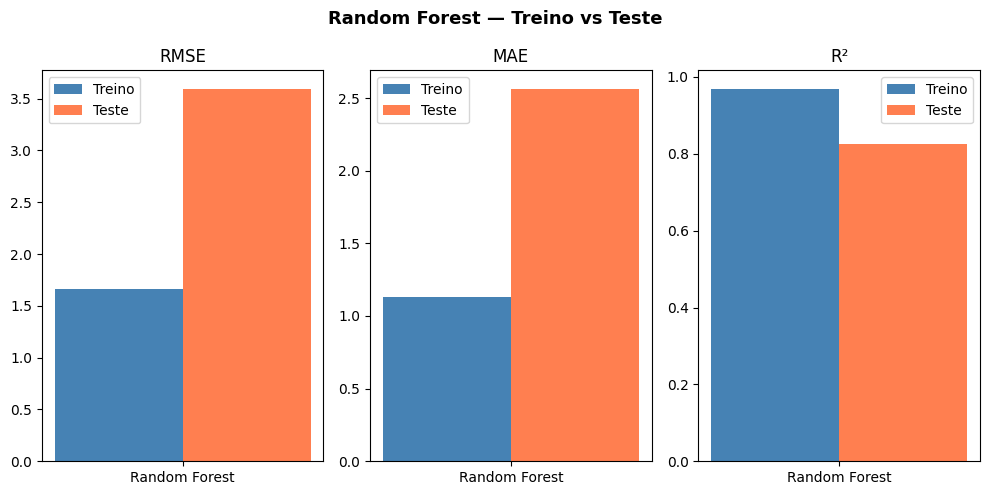

In [88]:
x = np.array([0])
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(10, 5))

# RMSE
axes[0].bar(x - width/2, [rmse_rf_train], width=width, label='Treino', color='steelblue')
axes[0].bar(x + width/2, [rmse_rf_test],  width=width, label='Teste',  color='coral')
axes[0].set_title('RMSE')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Random Forest'])
axes[0].legend()

# MAE
axes[1].bar(x - width/2, [mae_rf_train], width=width, label='Treino', color='steelblue')
axes[1].bar(x + width/2, [mae_rf_test],  width=width, label='Teste',  color='coral')
axes[1].set_title('MAE')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Random Forest'])
axes[1].legend()

# R²
axes[2].bar(x - width/2, [r2_rf_train], width=width, label='Treino', color='steelblue')
axes[2].bar(x + width/2, [r2_rf_test],  width=width, label='Teste',  color='coral')
axes[2].set_title('R²')
axes[2].set_xticks(x)
axes[2].set_xticklabels(['Random Forest'])
axes[2].legend()

plt.suptitle('Random Forest — Treino vs Teste', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [89]:
def diagnostico_fit(rmse_train, rmse_test, 
                   mae_train, mae_test, 
                   r2_train, r2_test, 
                   nome_modelo):
    
    print(f"{nome_modelo}")
    print(f"RMSE treino: {rmse_train:.4f} | RMSE teste: {rmse_test:.4f}")
    print(f"MAE  treino: {mae_train:.4f}  | MAE  teste: {mae_test:.4f}")
    print(f"R2   treino: {r2_train:.4f} | R2   teste: {r2_test:.4f}")

    # Diferenças
    diff_r2   = r2_train - r2_test
    diff_rmse = rmse_test - rmse_train
    diff_mae  = mae_test - mae_train

    # Diagnóstico
    if r2_train > 0.9 and diff_r2 > 0.1 and diff_rmse > 0 and diff_mae > 0:
        print("Diagnóstico: Overfitting (sobreajuste)")
    
    elif r2_train < 0.7 and r2_test < 0.7:
        print("Diagnóstico: Underfitting (subajuste)")
    
    else:
        print("Diagnóstico: Bom ajuste")
    
diagnostico_fit(rmse_rf_train, rmse_rf_test, mae_rf_train, mae_rf_test,r2_rf_train, r2_rf_test,"Random Forest")


Random Forest
RMSE treino: 1.6594 | RMSE teste: 3.5936
MAE  treino: 1.1323  | MAE  teste: 2.5627
R2   treino: 0.9687 | R2   teste: 0.8267
Diagnóstico: Overfitting (sobreajuste)


#### Conclusões:
A avaliação de ajuste do modelo **Random Forest** baseou-se na comparação direta entre o desempenho no conjunto de treino e no conjunto de teste. A lógica implementada define que existe um cenário de sobreajuste (_Overfitting)_ quando o modelo apresenta um desempenho de treino excecional, mas sofre uma degradação significativa ao ser exposto a dados novos.
Esta degradação de ajuste é avaliada através da diferença entre métricas. Considerou-se que, quando a diferença entre o R² de treino e o R² de teste ultrapassa de 0.1 (ou 10%),ocorre sobreajuste (_Overfitting_), o que se verificou no presente caso.
O **Random Forest** apresenta sobreajuste (_Overfitting_), com um valor de R² de treino (0.97)  muito superior ao de teste (0.83), indicando que o modelos se ajusta demasiado aos dados de treino. Este será sujeito a uma sintonização fina de hiperparâmetros com o objetivo de reduzir o sobreajuste (_Overfitting_) e melhorar a capacidade de generalização.


## Sintonização Fina (Hyperparameter Tuning)
(Natacha Zhang)

In [90]:
param_grid_rf = {
    'n_estimators':      [100, 200, 300,400],
    'max_depth':         [None,5, 10, 15],
    'min_samples_split': [2, 5, 10],
}

gs_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf, cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1, verbose=0
)

gs_rf.fit(X_train, y_train)

rf_tuned        = gs_rf.best_estimator_
y_pred_rf_tuned = rf_tuned.predict(X_test)
rmse_rf_tuned   = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))
mae_rf_tuned    = mean_absolute_error(y_test, y_pred_rf_tuned)
r2_rf_tuned     = r2_score(y_test, y_pred_rf_tuned)

print('Randon Forest — Melhores hiperparâmetros:', gs_rf.best_params_)
print(f'  RMSE Teste (otimizado): {rmse_rf_tuned:.4f}')
print(f'  MAE  Teste (otimizado): {mae_rf_tuned:.4f}')
print(f'  R²   Teste (otimizado): {r2_rf_tuned:.4f}')

Randon Forest — Melhores hiperparâmetros: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
  RMSE Teste (otimizado): 3.5936
  MAE  Teste (otimizado): 2.5627
  R²   Teste (otimizado): 0.8267


#### Observações:

Após a sintonização fina de hiperparâmetros através do _GridSearchCV_, o **Random Forest** não registou melhorias após o a sintonização, mantendo os resultados de testes inalterados.
Apesar do alargamento intencional do intervalo de 'n_estimators', o modelo convergiu consistentemente para 100 árvores e a tentativa de limitar a complexidade através da remoção do valor None em 'max_depth' resultou em piores desempenhos preditivos.

## Validação de Robustez
(Sofia Tanganho)

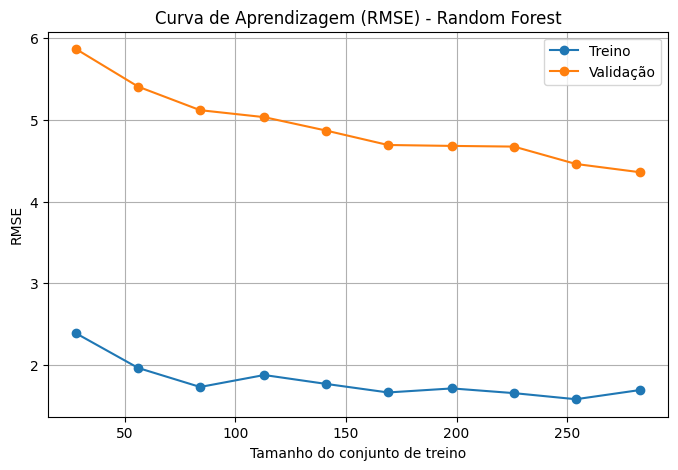

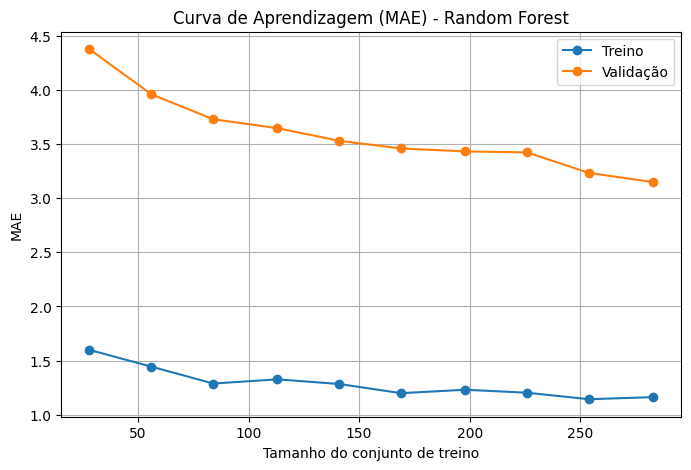

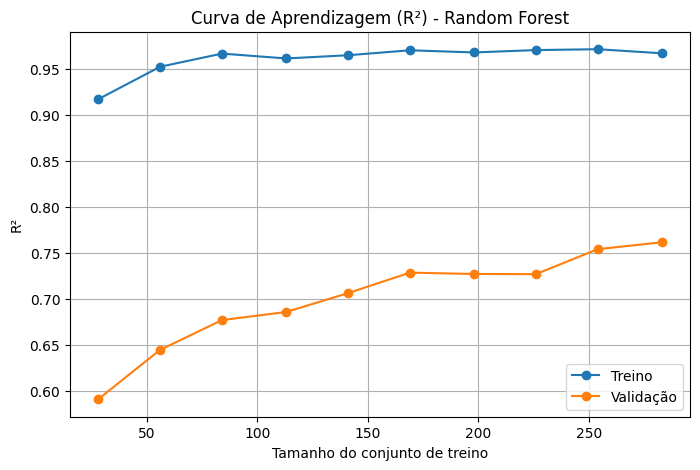

In [91]:
def plot_learning_curves_completo(model, X, y, nome_modelo):
    metricas = [
        ('neg_root_mean_squared_error', 'RMSE'),
        ('neg_mean_absolute_error', 'MAE'),
        ('r2', 'R²')
    ]

    for scoring, label in metricas:
        train_sizes, train_scores, test_scores = learning_curve(
            model, 
            X, 
            y, 
            cv=5, 
            scoring=scoring, 
            train_sizes=np.linspace(0.1, 1.0, 10), 
            n_jobs=-1
        )

        if scoring.startswith('neg_'):
            train_mean = -train_scores.mean(axis=1)
            test_mean = -test_scores.mean(axis=1)
        else:
            train_mean = train_scores.mean(axis=1)
            test_mean = test_scores.mean(axis=1)

        plt.figure(figsize=(8, 5))
        plt.plot(train_sizes, train_mean, 'o-', label='Treino')
        plt.plot(train_sizes, test_mean, 'o-', label='Validação')
        plt.title(f'Curva de Aprendizagem ({label}) - {nome_modelo}')
        plt.xlabel('Tamanho do conjunto de treino')
        plt.ylabel(label)
        plt.legend()
        plt.grid()
        plt.show()

if 'rf' in globals():
    plot_learning_curves_completo(rf, X_train, y_train, "Random Forest")

#### Observações:

As curvas de aprendizagem para as três métricas confirmam os diagnósticos anteriores. O **Random Forest** apresenta uma _gap_ considerável entre treino e validação que se vai reduzindo à medida que o conjunto de treino aumenta, indicando sobreajuste (_overfitting_) moderado com tendência a melhorar com mais dados.


## Validação Cruzada (_K-Fold Cross-Validation_)
(Diana Figueiredo)

K-Fold Cross-Validation (k=10)
        Modelo  RMSE Média  RMSE Std  MAE Média  MAE Std  R2 Média  R2 Std
Random Forest       4.0259    0.6446     2.8161   0.3153    0.7989  0.0641


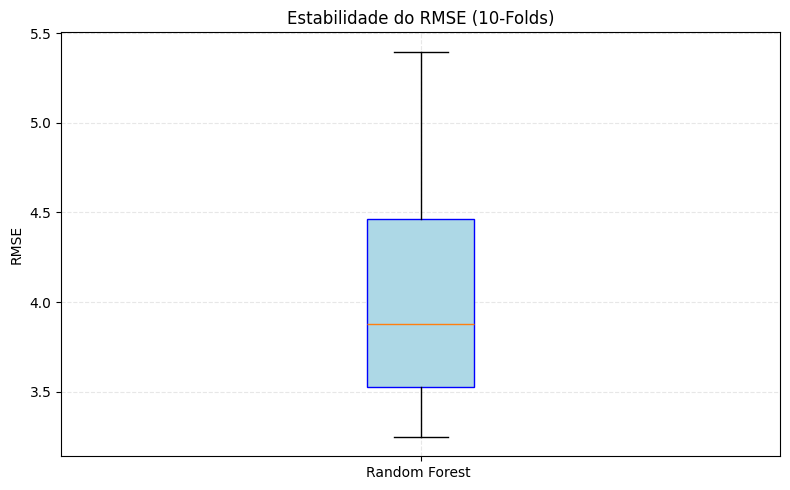

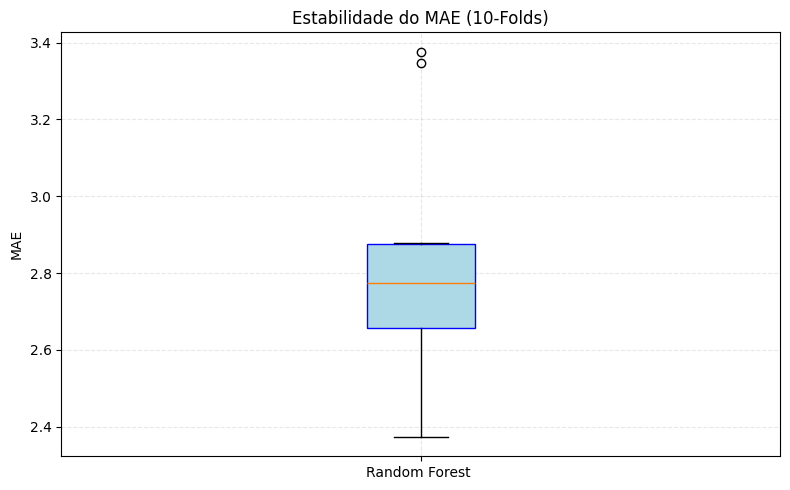

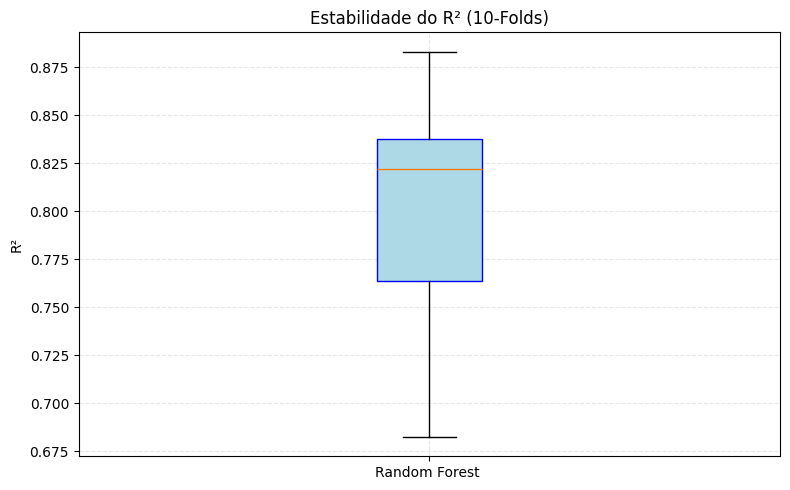

In [92]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

scoring = {
    'RMSE': 'neg_root_mean_squared_error',
    'MAE':  'neg_mean_absolute_error',
    'R2':   'r2'
}

modelos_cv = {
    'Random Forest ': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

resultados_cv = []
rmse_por_modelo = {}
mae_por_modelo = {}
r2_por_modelo = {}

for nome, modelo in modelos_cv.items():
    cv_res = cross_validate(modelo, X, y, cv=kf, scoring=scoring, n_jobs=-1)
    rmse = -cv_res['test_RMSE']
    mae  = -cv_res['test_MAE']
    r2   = cv_res['test_R2']

    rmse_por_modelo[nome] = rmse
    mae_por_modelo[nome]  = mae
    r2_por_modelo[nome]   = r2

    resultados_cv.append({
        'Modelo': nome,
        'RMSE Média': round(rmse.mean(), 4),
        'RMSE Std':   round(rmse.std(), 4),
        'MAE Média':  round(mae.mean(), 4),
        'MAE Std':    round(mae.std(), 4),
        'R2 Média':   round(r2.mean(), 4),
        'R2 Std':     round(r2.std(), 4),
    })

df_cv = pd.DataFrame(resultados_cv)
print("K-Fold Cross-Validation (k=10)")
print(df_cv.to_string(index=False))

def plot_boxplot(dados, titulo, ylabel):
    plt.figure(figsize=(8, 5))
    plt.boxplot(dados.values(), labels=dados.keys(), patch_artist=True, 
                boxprops=dict(facecolor='lightblue', color='blue'))
    plt.title(titulo)
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

plot_boxplot(rmse_por_modelo, 'Estabilidade do RMSE (10-Folds)', 'RMSE')
plot_boxplot(mae_por_modelo,  'Estabilidade do MAE (10-Folds)',  'MAE')
plot_boxplot(r2_por_modelo,   'Estabilidade do R² (10-Folds)',   'R²')

#### Observações:

A validação cruzada K-Fold (k=10) confirmou o **Random Forest**  apresentando o RMSE médio de 4.026 e o R² médio de 0.799 e com um MAE de 2.812.

## Análise de Resultados
(Natacha Zhang)

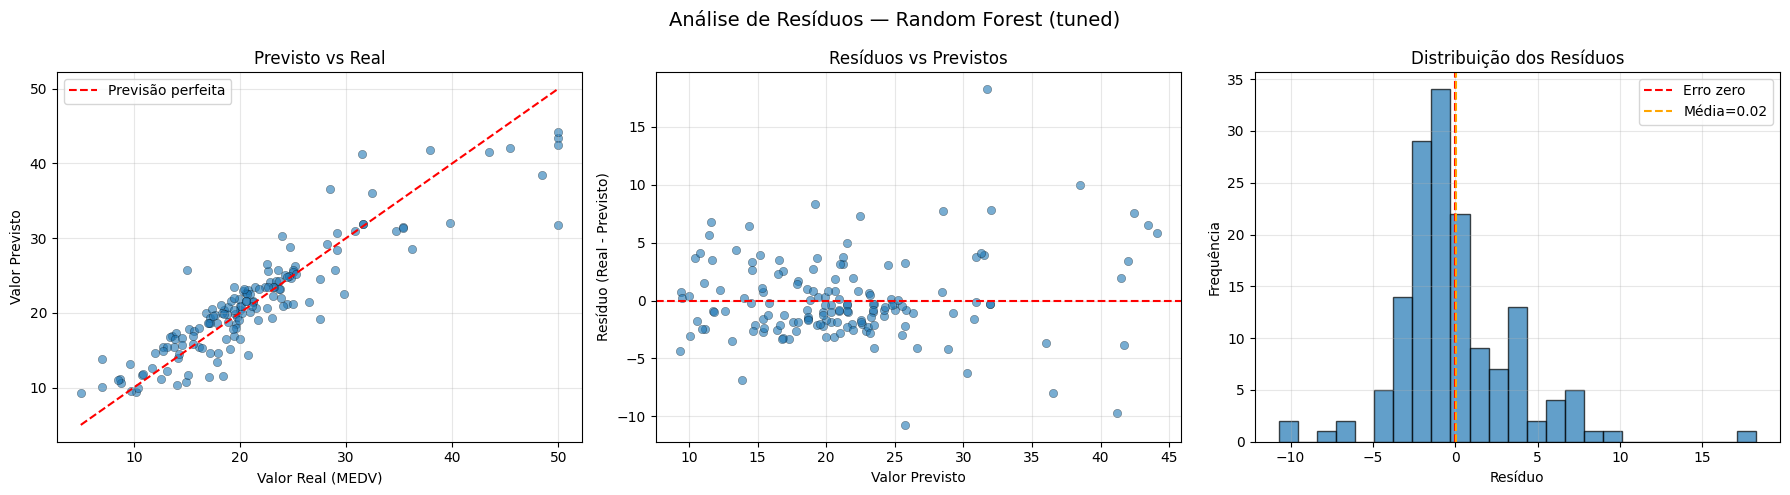


Estatísticas dos Resíduos — Random Forest (tuned)
  Resíduo médio  : 0.0244 
  Desvio padrão  : 3.5935
  Erro máximo    : 18.2760
  Erro mínimo    : -10.7300
  % casos |erro| < 2k$: 51.3%
  % casos |erro| < 5k$: 88.8%

Top 10 piores previsões:
     MEDV_real  MEDV_previsto  Erro_abs
371       50.0         31.724    18.276
375       15.0         25.730    10.730
203       48.5         38.500    10.000
229       31.5         41.213     9.713
409       27.5         19.181     8.319
290       28.5         36.517     8.017
180       39.8         31.981     7.819
181       36.2         28.484     7.716
225       50.0         42.432     7.568
473       29.8         22.494     7.306


In [93]:
# Modelo final — Random Forest (tuned)
nome_modelo_final = 'Random Forest (tuned)'
y_pred_final      = y_pred_rf_tuned
residuos          = y_test.values - y_pred_final

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Previsto vs Real
axes[0].scatter(y_test, y_pred_final, alpha=0.6, edgecolors='k', linewidths=0.3)
lim = [min(y_test.min(), y_pred_final.min()), max(y_test.max(), y_pred_final.max())]
axes[0].plot(lim, lim, 'r--', label='Previsão perfeita')
axes[0].set_xlabel('Valor Real (MEDV)')
axes[0].set_ylabel('Valor Previsto')
axes[0].set_title('Previsto vs Real')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Resíduos vs Previstos
axes[1].scatter(y_pred_final, residuos, alpha=0.6, edgecolors='k', linewidths=0.3)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel('Valor Previsto')
axes[1].set_ylabel('Resíduo (Real - Previsto)')
axes[1].set_title('Resíduos vs Previstos')
axes[1].grid(True, alpha=0.3)

# Distribuição dos Resíduos
axes[2].hist(residuos, bins=25, edgecolor='k', alpha=0.7)
axes[2].axvline(0, color='r', linestyle='--', label='Erro zero')
axes[2].axvline(residuos.mean(), color='orange', linestyle='--',
                label=f'Média={residuos.mean():.2f}')
axes[2].set_xlabel('Resíduo')
axes[2].set_ylabel('Frequência')
axes[2].set_title('Distribuição dos Resíduos')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Análise de Resíduos — {nome_modelo_final}', fontsize=14)
plt.tight_layout()
plt.show()

print(f'\nEstatísticas dos Resíduos — {nome_modelo_final}')
print(f'  Resíduo médio  : {residuos.mean():.4f} ')
print(f'  Desvio padrão  : {residuos.std():.4f}')
print(f'  Erro máximo    : {residuos.max():.4f}')
print(f'  Erro mínimo    : {residuos.min():.4f}')
print(f'  % casos |erro| < 2k$: {(np.abs(residuos) < 2).mean()*100:.1f}%')
print(f'  % casos |erro| < 5k$: {(np.abs(residuos) < 5).mean()*100:.1f}%')

df_erros = X_test.copy()
df_erros['MEDV_real']     = y_test.values
df_erros['MEDV_previsto'] = y_pred_final
df_erros['Erro_abs']      = np.abs(residuos)
df_erros = df_erros.sort_values('Erro_abs', ascending=False)

print('\nTop 10 piores previsões:')
print(df_erros[['MEDV_real', 'MEDV_previsto', 'Erro_abs']].head(10).to_string())

Importância de Variáveis:
   Feature  Random Forest
 IAH_stand       0.590397
 IQV_stand       0.116766
  AGE_norm       0.083127
INDUS_norm       0.077707
  TAX_norm       0.059965
   B_stand       0.049034
  ZN_stand       0.017987
      CHAS       0.005017


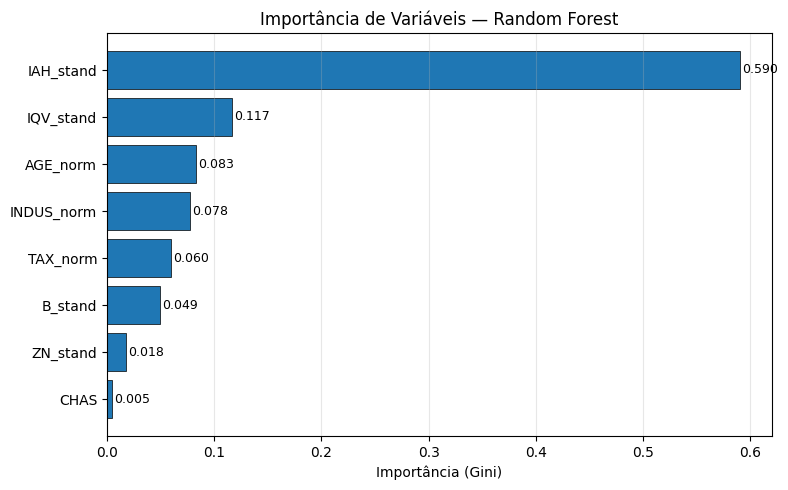

                 Modelo     RMSE       R2
  Random Forest (tuned) 3.593610 0.826688
Regressão Linear (base) 4.875704 0.680962


In [94]:
# Importância de Variáveis — Random Forest
feature_names = [
    'ZN_stand', 'INDUS_norm', 'CHAS', 'AGE_norm',
    'TAX_norm', 'B_stand', 'IQV_stand', 'IAH_stand'
]

importancias_rf = rf_tuned.feature_importances_

df_imp = pd.DataFrame({
    'Feature':       feature_names,
    'Random Forest': importancias_rf,
}).sort_values('Random Forest', ascending=False)

print('Importância de Variáveis:')
print(df_imp.to_string(index=False))

df_plot = df_imp.sort_values('Random Forest', ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(df_plot['Feature'], df_plot['Random Forest'], edgecolor='k', linewidth=0.5)
ax.set_title('Importância de Variáveis — Random Forest', fontsize=12)
ax.set_xlabel('Importância (Gini)')
ax.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars, df_plot['Random Forest']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

resumo_final = pd.DataFrame([
    {'Modelo': 'Regressão Linear (base)', 'RMSE': rmse_bl,       'R2': r2_bl},
    {'Modelo': 'Random Forest (tuned)',   'RMSE': rmse_rf_tuned, 'R2': r2_rf_tuned},
]).sort_values('RMSE')

print(resumo_final.to_string(index=False))



#### Conclusões:

Após a avaliação dos modelos, o **Random Forest (tuned)** foi selecionado como modelo
final por apresentar o menor RMSE de teste 3.594 e o R² mais elevado 0.827,
explicando 82.7% da variância do preço das habitações. Representa uma melhoria de
1.28k$ face ao modelo baseline de Regressão Linear (RMSE = 4.876).

A análise de resíduos confirmou que o modelo não apresenta bias sistemático
(resíduo médio = 0.02), com 51.3% das previsões com erro inferior a 2k$ e
88.8% com erro inferior a 5k$. Os piores casos concentram-se em habitações
com MEDV fixado em 50.0, reforçando o efeito de censura já identificado anteriormente.

Relativamente à importância de variáveis, o `IAH_stand` destaca-se como o preditor
mais relevante (importância = 0.590), validando a criação desta variável composta e o
seu contributo para a capacidade preditiva do modelo.

## Objetivo 2: Criar um modelo de Clustering para segmentar as habitações em perfis distintos com base nas suas características socioeconómicas, habitacionais e ambientais, validado pelo método do cotovelo e por um Coeficiente de Silhueta (>0.50), até ao Milestone 3
### Baseline: 
- Kmeans
### Algoritmos candidatos:
-  KMeans otimizado
- Agglomerative
- DBSCAN

(Sofia Tanganho)

In [95]:
feature_priority = {
    "ZN": ["ZN_stand", "ZN_norm", "ZN"],
    "INDUS": ["INDUS_stand", "INDUS_norm", "INDUS"],
    "CHAS": ["CHAS"],
    "AGE": ["AGE_stand", "AGE_norm", "AGE"],
    "TAX": ["TAX_stand", "TAX_norm", "TAX"],
    "B": ["B_stand", "B_norm", "B"],
    "IQV": ["IQV_stand", "IQV_norm", "IQV"],
    "IAH": ["IAH_stand", "IAH_norm", "IAH"],
}


selected_features = []
feature_origin_map = {}

for base_name, candidates in feature_priority.items():
    chosen = next((col for col in candidates if col in df.columns), None)
    if chosen is not None:
        selected_features.append(chosen)
        feature_origin_map[chosen] = base_name

if not selected_features:
    raise ValueError("Nenhuma das colunas esperadas para clustering foi encontrada no dataframe.")

X = df[selected_features].copy()

print("Variáveis usadas no clustering:")
print(selected_features)
print("\nShape do dataset de clustering:", X.shape)

Variáveis usadas no clustering:
['ZN_stand', 'INDUS_norm', 'CHAS', 'AGE_norm', 'TAX_norm', 'B_stand', 'IQV_stand', 'IAH_stand']

Shape do dataset de clustering: (506, 8)


#### Observações: 

Antes de aplicar os algoritmos de agrupamento (_clustering_), foi necessário selecionar as variáveis mais adequadas. Para cada variável, foi definida uma ordem de prioridade (versão estandardizada, normalizada ou original) garantindo que todas as variáveis se encontram na mesma escala e contribuem de forma equilibrada para a formação dos clusters.

# Divisão em treino e teste para avaliar a estabilidade
(Sofia Tanganho)

In [96]:
X_train, X_test = train_test_split(X, test_size=0.30, random_state=42)

print("\nTrain:", X_train.shape)
print("Test :", X_test.shape)



Train: (354, 8)
Test : (152, 8)


In [97]:
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)


def get_valid_labels(labels):
    labels = np.asarray(labels)
    mask = labels != -1 
    valid_labels = labels[mask]
    return mask, valid_labels


def safe_silhouette(X_part, labels):
    X_part = np.asarray(X_part)
    labels = np.asarray(labels)

    mask, valid_labels = get_valid_labels(labels)
    n_clusters = len(set(valid_labels))

    if valid_labels.size == 0 or n_clusters < 2:
        return np.nan

    return silhouette_score(X_part[mask], valid_labels)


def safe_calinski(X_part, labels):
    X_part = np.asarray(X_part)
    labels = np.asarray(labels)

    mask, valid_labels = get_valid_labels(labels)
    n_clusters = len(set(valid_labels))

    if valid_labels.size == 0 or n_clusters < 2:
        return np.nan

    return calinski_harabasz_score(X_part[mask], valid_labels)


def safe_davies(X_part, labels):
    X_part = np.asarray(X_part)
    labels = np.asarray(labels)

    mask, valid_labels = get_valid_labels(labels)
    n_clusters = len(set(valid_labels))

    if valid_labels.size == 0 or n_clusters < 2:
        return np.nan

    return davies_bouldin_score(X_part[mask], valid_labels)


def count_clusters(labels):
    labels = np.asarray(labels)
    unique = set(labels)
    if -1 in unique:
        unique.remove(-1)
    return len(unique)



def evaluate_on_split(model, X_part):
    labels = model.fit_predict(X_part)

    silhouette = safe_silhouette(X_part, labels)
    calinski = safe_calinski(X_part, labels)
    davies = safe_davies(X_part, labels)

    n_clusters = count_clusters(labels)
    noise = int(np.sum(np.asarray(labels) == -1))
    inertia = getattr(model, "inertia_", np.nan)

    return {
        "labels": labels,
        "silhouette": silhouette,
        "calinski": calinski,
        "davies": davies,
        "n_clusters": n_clusters,
        "noise_points": noise,
        "inertia": inertia
    }


def evaluate_train_test(model_train, model_test, model_name):
    train_res = evaluate_on_split(model_train, X_train)
    test_res  = evaluate_on_split(model_test, X_test)

    return {
        "Modelo": model_name,

        "Silhouette_Treino": train_res["silhouette"],
        "Silhouette_Teste": test_res["silhouette"],

        "Calinski_Treino": train_res["calinski"],
        "Calinski_Teste": test_res["calinski"],

        "Davies_Treino": train_res["davies"],
        "Davies_Teste": test_res["davies"],

        "Clusters_Treino": train_res["n_clusters"],
        "Clusters_Teste": test_res["n_clusters"],

        "Ruido_Treino": train_res["noise_points"],
        "Ruido_Teste": test_res["noise_points"],

        "Inertia_Treino": train_res["inertia"],
        "Inertia_Teste": test_res["inertia"],

        "Labels_Treino": train_res["labels"],
        "Labels_Teste": test_res["labels"]
    }

# Baseline - KMeans
(Natacha Zhang)

In [98]:
baseline_model = KMeans(random_state=42, n_init="auto")

baseline_res = evaluate_train_test(
    baseline_model,
    KMeans(random_state=42, n_init="auto"),
    "Baseline - KMeans default"
)

print("Kmeans")

# Silhouette
print(f"Silhouette Treino: {baseline_res['Silhouette_Treino']:.4f}")
print(f"Silhouette Teste : {baseline_res['Silhouette_Teste']:.4f}")

# Calinski-Harabasz
print(f"Calinski-Harabasz Treino: {baseline_res['Calinski_Treino']:.4f}")
print(f"Calinski-Harabasz Teste : {baseline_res['Calinski_Teste']:.4f}")

# Davies-Bouldin
print(f"Davies-Bouldin Treino: {baseline_res['Davies_Treino']:.4f}")
print(f"Davies-Bouldin Teste : {baseline_res['Davies_Teste']:.4f}")

# Clusters
print(f"Clusters Treino  : {baseline_res['Clusters_Treino']}")
print(f"Clusters Teste   : {baseline_res['Clusters_Teste']}")

Kmeans
Silhouette Treino: 0.3170
Silhouette Teste : 0.3325
Calinski-Harabasz Treino: 185.2667
Calinski-Harabasz Teste : 131.5455
Davies-Bouldin Treino: 0.9667
Davies-Bouldin Teste : 0.8541
Clusters Treino  : 8
Clusters Teste   : 8


#### Observações:

O modelo baseline **KMeans** com os parâmetros por omissão (k=8) obteve um **Coeficiente de Silhueta** de 0.317 (treino) e 0.333 (teste), valores abaixo do objetivo SMART definido (Silhueta > 0.50), indicando que os clusters formados ainda não apresentam uma separação suficientemente clara. Este resultado serve de referência para comparação com os modelos candidatos a desenvolver.

ELBOW / SILHOUETTE (KMEANS)
 k     inertia  silhouette
 2 1103.333518    0.447582
 3  813.344666    0.505966
 4  527.739657    0.554541
 5  436.764997    0.337227
 6  360.573948    0.386602
 7  335.008470    0.336393
 8  317.092325    0.316973
 9  276.099836    0.318110
10  241.495582    0.331603

Melhor k pelo Silhouette Score: 4 (score=0.5545)


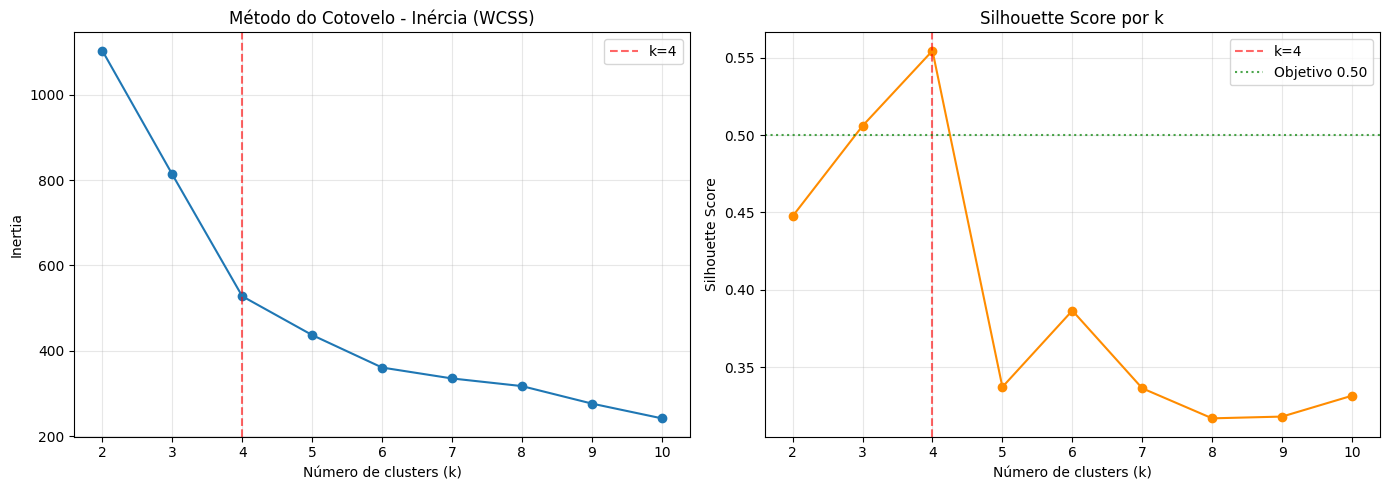

In [99]:
k_values = range(2, 11)
elbow_rows = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_train)
    elbow_rows.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": safe_silhouette(X_train, labels)
    })

elbow_df = pd.DataFrame(elbow_rows)
best_k = int(elbow_df.loc[elbow_df["silhouette"].idxmax(), "k"])
best_k_sil = elbow_df["silhouette"].max()

print("ELBOW / SILHOUETTE (KMEANS)")
print(elbow_df.to_string(index=False))
print(f"\nMelhor k pelo Silhouette Score: {best_k} (score={best_k_sil:.4f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(elbow_df["k"], elbow_df["inertia"], marker="o")
axes[0].axvline(best_k, linestyle="--", color="red", alpha=0.6, label=f"k={best_k}")
axes[0].set_title("Método do Cotovelo - Inércia (WCSS)")
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(elbow_df["k"], elbow_df["silhouette"], marker="o", color="darkorange")
axes[1].axvline(best_k, linestyle="--", color="red", alpha=0.6, label=f"k={best_k}")
axes[1].axhline(0.50, linestyle=":", color="green", alpha=0.7, label="Objetivo 0.50")
axes[1].set_title("Silhouette Score por k")
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### Observações:

O método do cotovelo identifica k=4 como o número ideal de clusters, ponto a partir do qual a redução da inércia (_WCSS_) abranda significativamente. Este valor é confirmado pelo Coeficiente de Silhueta, que atinge o seu máximo em k=4 (score=0.555), superando o objetivo SMART definido (Silhueta > 0.50). Os valores de k=3 (0.506) e k=4 (0.555) são os únicos que atingem o objetivo, sendo k=4 o mais equilibrado entre qualidade de clustering e número de perfis distintos.

### KMeans otimizado com k = 4

(Diana Figueiredo)

In [112]:
# KMeans otimizado
kmeans_tuned_res = evaluate_train_test(
    KMeans(n_clusters=best_k, random_state=42, n_init="auto"),
    KMeans(n_clusters=best_k, random_state=42, n_init="auto"),
    f"KMeans otimizado (k={best_k})"
)

results_df = pd.DataFrame([{
    "Métrica": "Silhouette Score",
    "Treino": kmeans_tuned_res["Silhouette_Treino"],
    "Teste": kmeans_tuned_res["Silhouette_Teste"]
}, {
    "Métrica": "Calinski-Harabasz",
    "Treino": kmeans_tuned_res["Calinski_Treino"],
    "Teste": kmeans_tuned_res["Calinski_Teste"]
}, {
    "Métrica": "Davies-Bouldin",
    "Treino": kmeans_tuned_res["Davies_Treino"],
    "Teste": kmeans_tuned_res["Davies_Teste"]
}])

print(results_df.to_string(index=False))

          Métrica     Treino      Teste
 Silhouette Score   0.554541   0.506473
Calinski-Harabasz 216.176058 118.958296
   Davies-Bouldin   0.645678   0.803111


#### Observações:

Com o valor ótimo de k definido, treinou-se o modelo _KMeans_ otimizado com 4 clusters. As métricas obtidas revelam um desempenho consistente entre treino e teste, o que indica boa capacidade de generalização da segmentação. O _Silhouette Score_ atinge 0,5545 no treino e 0,5065 no teste, acima do objetivo SMART (Silhueta > 0,50),mas se situe próximo do limiar. Contudo, a degradação mais acentuada no índice de Calinski-Harabasz (216,18 no treino vs 118,96 no teste) e a subida do Davies-Bouldin (0,6457 vs 0,8031) indicam que os clusters são menos compactos e separados no conjunto de teste, sugerindo alguma sensibilidade do modelo aos dados de treino.

### Agglomerative 
(Sofia Tanganho)

In [113]:
# Agglomerative
agg = AgglomerativeClustering() 
agg_res = evaluate_train_test(
    AgglomerativeClustering(),
    AgglomerativeClustering(),
    "Agglomerative default"
)
print("AGGLOMERATIVE ")
print(f"Silhouette Treino: {agg_res['Silhouette_Treino']:.4f}")
print(f"Silhouette Teste : {agg_res['Silhouette_Teste']:.4f}")
print(f"Calinski-Harabasz Treino: {agg_res['Calinski_Treino']:.4f}")
print(f"Calinski-Harabasz Teste : {agg_res['Calinski_Teste']:.4f}")
print(f"Davies-Bouldin Treino: {agg_res['Davies_Treino']:.4f}")
print(f"Davies-Bouldin Teste : {agg_res['Davies_Teste']:.4f}")
print(f"Clusters Treino: {agg_res['Clusters_Treino']}")
print(f"Clusters Teste : {agg_res['Clusters_Teste']}")
print(f"Ruído Treino: {agg_res['Ruido_Treino']}")
print(f"Ruído Teste : {agg_res['Ruido_Teste']}")

AGGLOMERATIVE 
Silhouette Treino: 0.4989
Silhouette Teste : 0.5868
Calinski-Harabasz Treino: 125.9729
Calinski-Harabasz Teste : 90.4516
Davies-Bouldin Treino: 0.8312
Davies-Bouldin Teste : 0.7782
Clusters Treino: 2
Clusters Teste : 2
Ruído Treino: 0
Ruído Teste : 0


#### Observações:
O modelo Agglomerative Clustering apresentou resultados satisfatórios, com um Silhouette Score de 0,4989 no treino e 0,5868 no teste, sendo que no conjunto de teste atingiu o objetivo SMART (Silhueta > 0,50). O índice de Calinski-Harabasz foi de 125,97 no treino e 90,45 no teste, e o índice de Davies-Bouldin de 0,8312 no treino e 0,7782 no teste.
O modelo identificou consistentemente 2 clusters tanto no treino como no teste, sem qualquer ponto de ruído, o que demonstra estabilidade e robustez face a diferentes subconjuntos de dados.

### DBSCAN
(Natacha Zhang)

In [114]:
#DBSCAN
dbscan_res = evaluate_train_test(
    DBSCAN(),
    DBSCAN(),
    "DBSCAN default"
)
print("DBSCAN")
print(f"Silhouette Treino: {dbscan_res['Silhouette_Treino']:.4f}")
print(f"Silhouette Teste : {dbscan_res['Silhouette_Teste']:.4f}")
print(f"Calinski-Harabasz Treino: {dbscan_res['Calinski_Treino']:.4f}")
print(f"Calinski-Harabasz Teste : {dbscan_res['Calinski_Teste']:.4f}")
print(f"Davies-Bouldin Treino: {dbscan_res['Davies_Treino']:.4f}")
print(f"Davies-Bouldin Teste : {dbscan_res['Davies_Teste']:.4f}")
print(f"Clusters Treino: {dbscan_res['Clusters_Treino']}")
print(f"Clusters Teste : {dbscan_res['Clusters_Teste']}")
print(f"Ruído Treino: {dbscan_res['Ruido_Treino']}")
print(f"Ruído Teste : {dbscan_res['Ruido_Teste']}")

DBSCAN
Silhouette Treino: 0.2332
Silhouette Teste : 0.3459
Calinski-Harabasz Treino: 110.3760
Calinski-Harabasz Teste : 109.8801
Davies-Bouldin Treino: 0.7510
Davies-Bouldin Teste : 0.6706
Clusters Treino: 10
Clusters Teste : 4
Ruído Treino: 112
Ruído Teste : 56


#### Observações:

O modelo DBSCAN apresentou resultados moderados, com um Silhouette Score de 0,2332 no treino e 0,3459 no teste, não atingindo o objetivo SMART 2 (Silhueta > 0,50). O índice de Calinski-Harabasz foi de 110,38 no treino e 109,88 no teste, e o índice de Davies-Bouldin de 0,751 no treino e 0,671 no teste.
A diferença no número de clusters obtidos (10 no treino e 4 no teste), bem como o elevado número de pontos de ruído (112 no treino e 56 no teste), revelam instabilidade do modelo face a diferentes subconjuntos de dados, o que constitui uma limitação relevante na sua aplicação prática.

### Tabela Comparativa 
(Natacha Zhang)

In [123]:
# TABELA COMPARATIVA
comparison_df = pd.DataFrame([
    {k: v for k, v in baseline_res.items() if not k.startswith("Labels")},
    {k: v for k, v in kmeans_tuned_res.items() if not k.startswith("Labels")},
    {k: v for k, v in agg_res.items() if not k.startswith("Labels")},
    {k: v for k, v in dbscan_res.items() if not k.startswith("Labels")},
])
comparison_df["Gap_Treino_Teste"] = (
    comparison_df["Silhouette_Treino"] - comparison_df["Silhouette_Teste"]
).abs()
comparison_df = comparison_df.sort_values(
    by=["Silhouette_Teste", "Gap_Treino_Teste"],
    ascending=[False, True]
).reset_index(drop=True)

cols = [c for c in comparison_df.columns if not c.startswith(("Labels", "Inertia"))]
display(comparison_df[cols])

,Modelo,Silhouette_Treino,Silhouette_Teste,Calinski_Treino,Calinski_Teste,Davies_Treino,Davies_Teste,Clusters_Treino,Clusters_Teste,Ruido_Treino,Ruido_Teste,Gap_Treino_Teste
0,Agglomerative default,0.498893,0.586841,125.972870,90.451583,0.831183,0.778204,2,2,0,0,0.087947
1,KMeans otimizado (k=4),0.554541,0.506473,216.176058,118.958296,0.645678,0.803111,4,4,0,0,0.048068
2,DBSCAN default,0.233152,0.345856,110.376029,109.880096,0.750970,0.670593,10,4,112,56,0.112704
3,Baseline - KMeans default,0.316973,0.332521,185.266699,131.545467,0.966697,0.854103,8,8,0,0,0.015548


#### Observações:
O modelo escolhido para a segmentação final das habitações foi o _AgglomerativeClustering_, por apresentar o melhor equilíbrio global entre as métricas avaliadas. Apesar de o _KMeans_ otimizado (k=4) registar um _Silhouette Score_ ligeiramente superior no treino (0,5545 vs 0,4989), o _Agglomerative Clustering_ supera-o no conjunto de teste (0,5868 vs 0,5064),não apresenta qualquer ponto de ruído e revela uma diferença reduzida entre treino e teste no _Silhouette Score_ (0.088), demonstrando maior estabilidade e capacidade de generalização.
O DBSCAN foi excluído por não atingir o objetivo SMART no _Silhouette Score_ (0,2332 no treino e 0,3459 no teste), pelo elevado número de pontos de ruído (112 no treino e 56 no teste) e pela instabilidade no número de clusters entre treino e teste (10 vs 4). O _KMeans default_(_Baseline_) foi igualmente excluído do melhor modelo por apresentar os piores valores de _Silhouette Score_ (0,3170 e 0,3325) e o índice de _Davies-Bouldin_ mais elevado (0,9667 no treino), indicando fraca separação entre _clusters_.
O _Agglomerative Clustering_ identificou de forma consistente 2 _clusters_ em ambos os conjuntos, sem ruído, atingindo o objetivo SMART no teste (Silhouette > 0,50) e apresentando um _Davies-Bouldin_ competitivo. Estes fatores, em conjunto com a sua robustez e interpretabilidade, tornam-no a escolha mais adequada para a segmentação final.

### Sintonização Fina (Hyperparameter Tuning)
(Natacha Zhang)

In [116]:
from sklearn.cluster import AgglomerativeClustering

param_grid_agg = {
    "n_clusters": list(range(2, 11)),
    "linkage": ["ward", "complete", "average"]
}

agg_results = []
for params in ParameterGrid(param_grid_agg):
    res = evaluate_train_test(
        AgglomerativeClustering(**params),
        AgglomerativeClustering(**params),
        f"Agglomerative {params}"
    )
    agg_results.append((params, res))

best_agg_params, best_agg_res = max(
    agg_results,
    key=lambda x: -999 if np.isnan(x[1]["Silhouette_Teste"]) else x[1]["Silhouette_Teste"]
)

print("Agglomerative — Melhores hiperparâmetros:", best_agg_params)
print(f"  Silhouette Treino: {best_agg_res['Silhouette_Treino']:.4f}")
print(f"  Silhouette Teste : {best_agg_res['Silhouette_Teste']:.4f}")
print(f"  Calinski-Harabasz Treino: {best_agg_res['Calinski_Treino']:.4f}")
print(f"  Calinski-Harabasz Teste : {best_agg_res['Calinski_Teste']:.4f}")
print(f"  Davies-Bouldin Treino: {best_agg_res['Davies_Treino']:.4f}")
print(f"  Davies-Bouldin Teste : {best_agg_res['Davies_Teste']:.4f}")
print(f"  Agrupamentos Treino: {best_agg_res['Clusters_Treino']}")
print(f"  Agrupamentos Teste : {best_agg_res['Clusters_Teste']}")

Agglomerative — Melhores hiperparâmetros: {'linkage': 'complete', 'n_clusters': 2}
  Silhouette Treino: 0.5889
  Silhouette Teste : 0.7363
  Calinski-Harabasz Treino: 84.7915
  Calinski-Harabasz Teste : 21.4427
  Davies-Bouldin Treino: 0.7157
  Davies-Bouldin Teste : 0.1781
  Agrupamentos Treino: 2
  Agrupamentos Teste : 2


#### Observações:

Após o ajuste de hiperparâmetros, o _Agglomerative Clustering_ com linkage='complete' e n_clusters=2 registou uma melhoria significativa face à versão _default_. O _SilhouetteScore_ passou de 0,4989 para 0,5889 no treino e de 0,5868 para 0,7363 no teste.
O índice de _Davies-Bouldin_ no teste desceu de 0,7782 para 0,1781, indicando _clusters_ substancialmente mais bem separados. Note-se, contudo, que o índice de _Calinski-Harabasz_ no teste diminuiu consideravelmente (de 90,45 para 21,44), o que pode refletir _clusters_ de dimensão desigual. O modelo manteve consistentemente 2 _clusters_ em ambos os conjuntos, sem qualquer ponto de ruído, confirmando a sua estabilidade e capacidade de generalização.

In [105]:
best_model_name = "Agglomerative"
final_model = AgglomerativeClustering(**best_agg_params)
final_labels = final_model.fit_predict(X)

### Análise de Estabilidade (_Bootstrap_)
(Natacha Zhang)

In [117]:
np.random.seed(42)
bootstrap_scores = []

for i in range(30):
    X_sample = resample(X, replace=True, random_state=i)
    model = AgglomerativeClustering(**best_agg_params)
    labels = model.fit_predict(X_sample)
    score = safe_silhouette(X_sample, labels)
    bootstrap_scores.append(score)

bootstrap_scores = np.array(bootstrap_scores, dtype=float)
boot_mean = np.nanmean(bootstrap_scores)
boot_std  = np.nanstd(bootstrap_scores)
boot_ci_low  = np.percentile(bootstrap_scores, 2.5)
boot_ci_high = np.percentile(bootstrap_scores, 97.5)

print(f"Bootstrap Silhouette Média    : {boot_mean:.4f}")
print(f"Bootstrap Desv. Padrão        : {boot_std:.4f}")
print(f"Intervalo de Confiança 95%    : [{boot_ci_low:.4f}, {boot_ci_high:.4f}]")

Bootstrap Silhouette Média    : 0.6476
Bootstrap Desv. Padrão        : 0.0754
Intervalo de Confiança 95%    : [0.5300, 0.7553]


#### Observações:
A análise de estabilidade por (_Bootstrap_) de 30 interações confirmou a robustez do modelo _Agglomerative Clustering_, com um Silhouette médio de 0.6476 e um intervalo de confiança a 95% de [0.5300, 0.7553]. O limite inferior do intervalo mantém-se acima do critério mínimo definido (>0.50), o que valida a estabilidade dos _clusters_ independentemente da amostra utilizada.

### Silhouette Plot do Modelo Final 
(Sofia Tanganho)

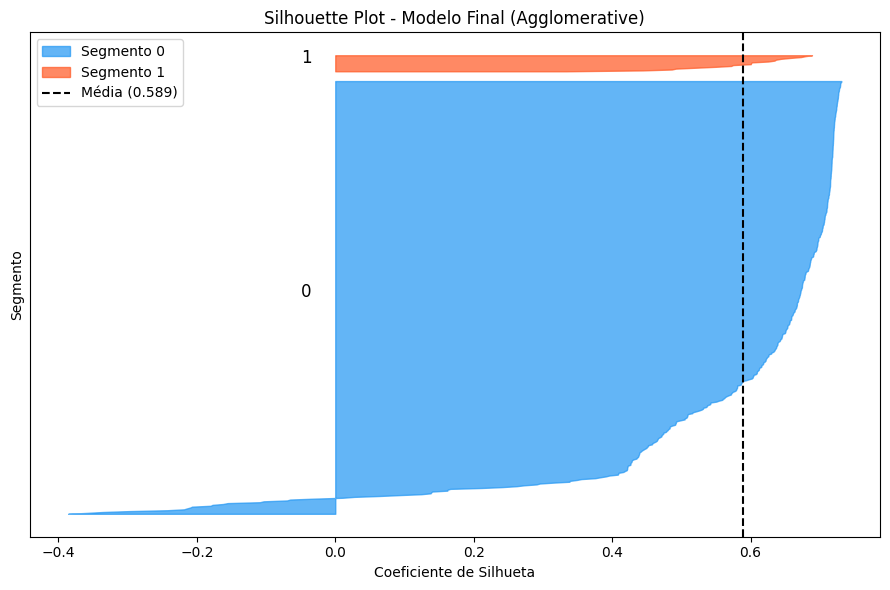

In [118]:
X_array = np.asarray(X)
sample_silhouette_values = silhouette_samples(X_array, final_labels)
avg_score = silhouette_score(X_array, final_labels)

fig, ax = plt.subplots(figsize=(9, 6))
y_lower = 10
cores = ["#2196F3", "#FF5722"]

for cluster_id in [0, 1]:
    cluster_vals = sample_silhouette_values[final_labels == cluster_id]
    cluster_vals.sort()
    size_cluster = len(cluster_vals)
    y_upper = y_lower + size_cluster
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_vals,
                     alpha=0.7, color=cores[cluster_id], label=f"Segmento {cluster_id}")
    ax.text(-0.05, y_lower + 0.5 * size_cluster, str(cluster_id), fontsize=12)
    y_lower = y_upper + 10

ax.axvline(x=avg_score, linestyle="--", color="black", label=f"Média ({avg_score:.3f})")
ax.set_title("Silhouette Plot - Modelo Final (Agglomerative)")
ax.set_xlabel("Coeficiente de Silhueta")
ax.set_ylabel("Segmento")
ax.set_yticks([])
ax.legend()
plt.tight_layout()
plt.show()

In [120]:
print("Contagem por segmento:")
print(pd.Series(final_labels).value_counts().sort_index().rename(index={0: "Segmento 0", 1: "Segmento 1"}))

Contagem por segmento:
Segmento 0    487
Segmento 1     19
Name: count, dtype: int64


#### Observações:
O _Silhouette Plot_ confirma a separação entre os dois segmentos. O Segmento 1, composto por apenas 19 habitações, apresenta uma barra compacta e uniforme, sugerindo boa coesão interna. O Segmento 0, sendo muito maior (487 habitações), apresenta maior heterogeneidade interna, com alguns pontos com coeficiente negativo, indicando que estão na fronteira entre os dois segmentos. A média global de 0.589, calculada sobre o conjunto de dados (_dataset_) completo, mantém-se acima do critério mínimo definido (>0.50).

### Visualização 2D dos segmentos
(Natacha Zhang)

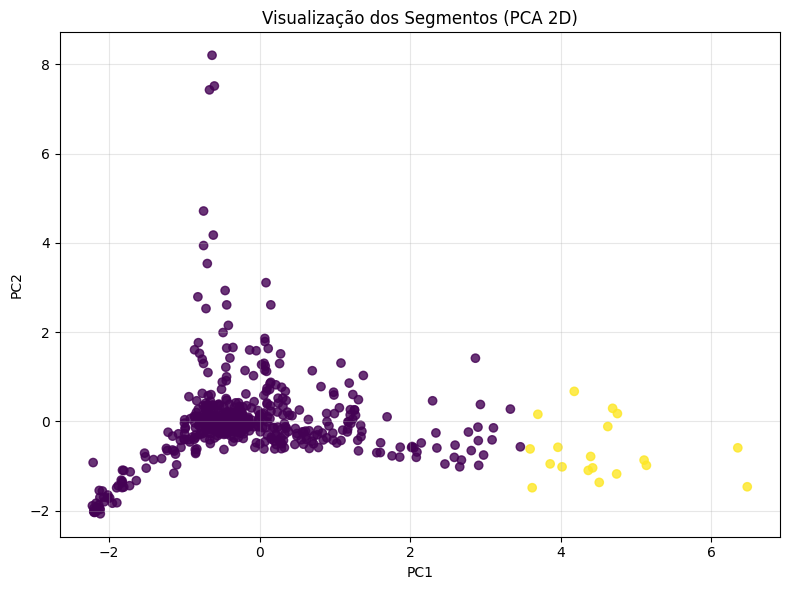

In [121]:
# VISUALIZAÇÃO 2D DOS SEGMENTOS (PCA)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=final_labels, alpha=0.8)
plt.title("Visualização dos Segmentos (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Observações:

A visualização dos segmentos em 2 dimensões (PCA) permite observar a separação espacial entre os dois segmentos identificados pelo modelo _Agglomerative Clustering_. O Segmento 0 (roxo) concentra a grande maioria das habitações, distribuindo-se pela região central e esquerda do gráfico. O Segmento 1 (amarelo), composto por apenas 19 habitações, aparece claramente separado na região direita, evidenciando características distintas que justificam a sua separação num grupo próprio.

### Perfil médio dos clusters 
(Diana Figueiredo)

PERFIL MÉDIO DOS SEGMENTOS
                 ZN      INDUS      CHAS        AGE         TAX           B  \
Segmento                                                                      
0          8.777207  11.487495  0.069815  69.999384  413.026694  355.402259   
1         77.657895   2.147368  0.052632  32.063158  285.473684  389.271579   

                IQV       IAH  
Segmento                       
0          9.246430  0.222562  
1         74.054352  0.230868  


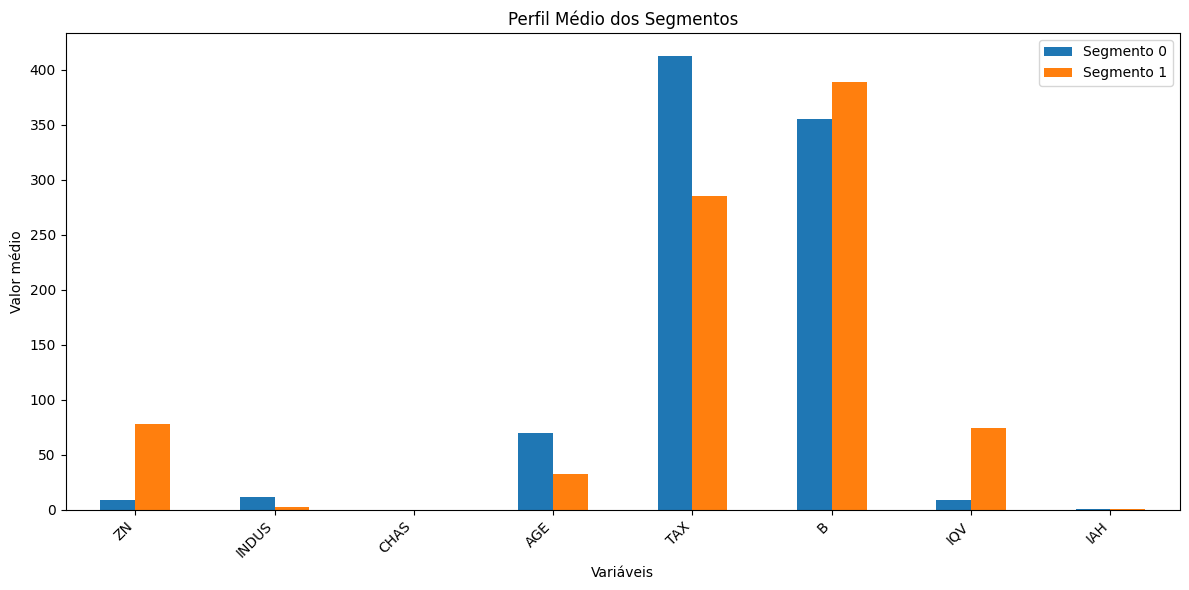

In [124]:
profile_df = pd.DataFrame()
for transformed_col in selected_features:
    base_name = feature_origin_map[transformed_col]
    if base_name in df.columns:
        profile_df[base_name] = df[base_name]
    else:
        profile_df[transformed_col] = df[transformed_col]
profile_df["Segmento"] = final_labels
profile_df_valid = profile_df[profile_df["Segmento"] != -1].copy()
cluster_profile = profile_df_valid.groupby("Segmento").mean(numeric_only=True)

print("PERFIL MÉDIO DOS SEGMENTOS")
print(cluster_profile)

cluster_profile.T.plot(kind="bar", figsize=(12, 6))
plt.title("Perfil Médio dos Segmentos")
plt.xlabel("Variáveis")
plt.ylabel("Valor médio")
plt.xticks(rotation=45, ha="right")
plt.legend(["Segmento 0", "Segmento 1"])
plt.tight_layout()
plt.show()

#### Conclusões:
O perfil médio dos segmentos revela características distintas entre os dois grupos identificados. O Segmento 1 apresenta valores claramente superiores nas variáveis ZN (77.7 vs 8.8) e IQV (74.1 vs 9.2), indicando habitações em zonas residenciais amplas e com maior índice de qualidade de vida. Em contraste, o Segmento 0 apresenta valores mais elevados de AGE (70.0 vs 32), TAX (413.0 vs 285.5) e INDUS (11.5 vs 2.1), representando habitações mais antigas, com maior carga fiscal e localizadas em zonas com maior presença industrial. O IAH apresenta valores semelhantes entre os dois segmentos (0.223 vs 0.231), não sendo uma variável discriminante relevante. A variável B é ligeiramente superior no Segmento 1 (389.3 vs 355.4), enquanto CHAS apresenta valores próximos em ambos os grupos.